# Nifty 50 — Buy Put Strategy Backtester
### Strategy: Bearish EMA 20 / EMA 200 Pullback on 5-Minute Chart
> **Timeframe:** 5-min | **Index:** ^NSEI | **Style:** Buy Put (bearish, tracked in index points)

## 1. Install & Import Libraries

In [14]:
# Install required libraries if not already available
# import subprocess, sys
# subprocess.run([sys.executable, "-m", "pip", "install", "yfinance", "pandas", "numpy",
#                 "matplotlib", "pytz", "-q"])

In [15]:
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pytz
from datetime import datetime, time

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Strategy Configuration (All Parameters)

In [16]:
# ─────────────────────────────────────────────
#  CONFIGURATION — edit these to tune the strategy
# ─────────────────────────────────────────────

TICKER          = "^NSEI"          # Nifty 50
INTERVAL        = "5m"             # 5-minute candles
PERIOD          = "60d"            # Max available for 5-min on yfinance

EMA_FAST        = 20               # Fast EMA period
EMA_SLOW        = 200              # Slow EMA period
WARMUP          = EMA_SLOW         # Discard first 200 candles

IST             = pytz.timezone("Asia/Kolkata")

SESSION_START   = time(9, 30)      # No entries before 9:30 AM IST
ENTRY_CUTOFF    = time(14, 30)     # No new entries at/after 2:30 PM IST
FORCE_EXIT_TIME = time(15, 15)     # Force-close all trades at 3:15 PM IST
SESSION_END     = time(15, 30)     # End of session (strip after-hours)

MAX_TRADES_DAY  = 4                # Max 4 trades per day
KILLSWITCH_SL   = 2                # Stop day after first 2 consecutive SLs
PULLBACK_WINDOW = 5                # Candles to look back for C5 validity check

SL_BUFFER       = 1.0              # Points above EMA_20 / signal high for SL
RR_RATIO        = 2.5              # Risk:Reward ratio for target
TRAIL_TRIGGER_R = 1.5              # Activate trailing after 1.5R profit
MAX_EMA_DISTANCE= 10.0             # Max points price can be below EMA 20 at entry

print("Configuration set.")

Configuration set.


## 3. Data Download, Timezone Conversion & Session Filtering

In [17]:
def download_data(ticker=TICKER, interval=INTERVAL, period=PERIOD):
    """Download OHLCV data from yfinance, convert to IST, filter to market session."""
    print(f"Downloading {ticker} [{interval}] for {period}...")
    raw = yf.download(ticker, interval=interval, period=period, auto_adjust=True, progress=False)

    # Flatten multi-level columns if present
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    # Convert index to IST
    if raw.index.tzinfo is None:
        raw = raw.tz_localize("UTC")
    raw = raw.tz_convert(IST)

    # Filter to market session 9:15 AM – 3:30 PM IST only
    raw = raw.between_time("09:15", "15:30")

    # Drop NaN rows
    raw.dropna(subset=["Open", "High", "Low", "Close"], inplace=True)

    print(f"Data loaded: {len(raw)} candles | {raw.index[0].date()} → {raw.index[-1].date()}")
    return raw


df_raw = download_data()
df_raw.head(3)

Data loaded: 4329 candles | 2025-12-11 → 2026-03-09


Price,Close,High,Low,Open,Volume
Datetime,,,,,
2025-12-11 09:15:00+05:30,25757.099609,25794.650391,25727.900391,25777.449219,0
2025-12-11 09:20:00+05:30,25774.599609,25796.300781,25755.449219,25755.949219,0
2025-12-11 09:25:00+05:30,25798.250000,25802.849609,25765.099609,25774.900391,0


## 4. EMA Calculation & Signal Conditions

In [18]:
def add_indicators_and_signals(df):
    """Add EMA 20, EMA 200 and all 5 signal condition flags."""
    df = df.copy()

    # ── EMAs ──────────────────────────────────────────────
    df["EMA20"]  = df["Close"].ewm(span=EMA_FAST,  adjust=False).mean()
    df["EMA200"] = df["Close"].ewm(span=EMA_SLOW, adjust=False).mean()

    # Discard warmup period (first 200 candles unreliable)
    df = df.iloc[WARMUP:].copy()

    # ── Signal Conditions ─────────────────────────────────
    # C1: Trend confirmation — close below BOTH EMAs
    df["C1"] = (df["Close"] < df["EMA20"]) & (df["Close"] < df["EMA200"])

    # C2: Bearish candle (red candle)
    df["C2"] = df["Close"] < df["Open"]

    # C3: Candle touches / closes at or below EMA20 (pullback touch)
    df["C3"] = (df["High"] >= df["EMA20"]) | (df["Close"] <= df["EMA20"])

    # C4: Not too far below EMA20 (entry must be near EMA, not far below)
    df["C4"] = df["Close"] >= (df["EMA20"] - MAX_EMA_DISTANCE)

    # C5: Valid pullback — all of the last N candles had close <= EMA20
    #     (price pulled back UP from below to touch EMA, not falling through)
    def valid_pullback(closes, ema20s, n=PULLBACK_WINDOW):
        result = np.zeros(len(closes), dtype=bool)
        for i in range(n, len(closes)):
            # Look at the N candles BEFORE current candle
            prev_closes = closes.iloc[i-n:i]
            prev_ema    = ema20s.iloc[i-n:i]
            # ALL prior closes must be <= their own EMA20 (price was below EMA)
            if (prev_closes.values <= prev_ema.values).all():
                result[i] = True
        return result

    df["C5"] = valid_pullback(df["Close"], df["EMA20"])

    # Combined signal
    df["SIGNAL"] = df["C1"] & df["C2"] & df["C3"] & df["C4"] & df["C5"]

    print(f"Indicators added. Total candles after warmup: {len(df)}")
    print(f"Total raw signals found: {df['SIGNAL'].sum()}")
    return df


df = add_indicators_and_signals(df_raw)
df[["Open", "High", "Low", "Close", "EMA20", "EMA200",
    "C1", "C2", "C3", "C4", "C5", "SIGNAL"]].tail(10)

Indicators added. Total candles after warmup: 4129
Total raw signals found: 42


Price,Open,High,Low,Close,EMA20,EMA200,C1,C2,C3,C4,C5,SIGNAL
Datetime,,,,,,,,,,,,
2026-03-09 14:40:00+05:30,23929.800781,23956.300781,23914.000000,23946.550781,23898.328016,24257.796629,False,False,True,True,False,False
2026-03-09 14:45:00+05:30,23946.949219,24016.849609,23939.300781,23981.050781,23906.206375,24255.042939,False,False,True,True,False,False
2026-03-09 14:50:00+05:30,23981.050781,24012.449219,23968.099609,24012.150391,23916.296281,24252.626098,False,False,True,True,False,False
2026-03-09 14:55:00+05:30,24011.650391,24018.550781,23991.349609,24008.800781,23925.106233,24250.199975,False,True,True,True,False,False
2026-03-09 15:00:00+05:30,24011.000000,24056.300781,23973.949219,24048.300781,23936.839047,24248.191028,False,False,True,True,False,False
2026-03-09 15:05:00+05:30,24049.400391,24075.849609,24021.599609,24033.650391,23946.059175,24246.056295,False,True,True,True,False,False
2026-03-09 15:10:00+05:30,24033.300781,24061.000000,24024.699219,24047.800781,23955.748852,24244.083604,False,False,True,True,False,False
2026-03-09 15:15:00+05:30,24047.699219,24056.150391,24037.800781,24039.650391,23963.739475,24242.049442,False,True,True,True,False,False
2026-03-09 15:20:00+05:30,24040.599609,24040.750000,24006.150391,24015.699219,23968.688022,24239.797201,False,True,True,True,False,False


## 5. Backtesting Engine

In [19]:
def run_backtest(df):
    """
    Core backtesting loop.
    Returns a DataFrame with one row per completed trade.
    """
    trades = []

    # Group by trading date
    df["date"] = df.index.date
    days = df["date"].unique()

    for day in days:
        day_df = df[df["date"] == day].copy()

        trades_today   = 0
        consec_sl      = 0      # consecutive SL count (non-TRAIL_SL)
        killed         = False  # kill-switch flag
        in_trade       = False

        # Trade state variables
        entry_price = sl = target = risk = trail_active = None
        entry_time  = entry_candle_idx = None

        for idx, row in day_df.iterrows():
            candle_time = idx.time()

            # ── Force-exit at 3:15 PM ─────────────────────
            if in_trade and candle_time >= FORCE_EXIT_TIME:
                pnl   = entry_price - row["Close"]
                r_mul = pnl / risk if risk else 0
                trades.append({
                    "date":       day,
                    "entry_time": entry_time,
                    "exit_time":  idx,
                    "entry":      round(entry_price, 2),
                    "sl":         round(sl, 2),
                    "target":     round(target, 2),
                    "exit":       round(row["Close"], 2),
                    "pnl_pts":    round(pnl, 2),
                    "r_multiple": round(r_mul, 2),
                    "result":     "TIME_EXIT",
                })
                in_trade = False
                break

            # ── Manage open trade ─────────────────────────
            if in_trade:
                current_pnl = entry_price - row["Low"]   # worst intra-candle
                current_ema = row["EMA20"]

                # Activate trailing once 1.5R profit reached
                if not trail_active and (entry_price - row["Low"]) >= TRAIL_TRIGGER_R * risk:
                    trail_active = True

                # Update trailing SL (never widen)
                if trail_active:
                    new_trail_sl = current_ema
                    if new_trail_sl < sl:   # only tighten (move down = profit direction for put)
                        sl = new_trail_sl

                # Check SL hit (price rose to SL level)
                if row["High"] >= sl:
                    exit_price = sl
                    pnl        = entry_price - exit_price
                    r_mul      = pnl / risk
                    result     = "TRAIL_SL" if trail_active else "SL"
                    trades.append({
                        "date":       day,
                        "entry_time": entry_time,
                        "exit_time":  idx,
                        "entry":      round(entry_price, 2),
                        "sl":         round(sl, 2),
                        "target":     round(target, 2),
                        "exit":       round(exit_price, 2),
                        "pnl_pts":    round(pnl, 2),
                        "r_multiple": round(r_mul, 2),
                        "result":     result,
                    })
                    in_trade = False
                    if result == "SL":
                        consec_sl += 1
                    else:
                        consec_sl = 0   # TRAIL_SL resets kill-switch counter
                    if consec_sl >= KILLSWITCH_SL:
                        killed = True
                    continue

                # Check Target hit
                if row["Low"] <= target:
                    exit_price = target
                    pnl        = entry_price - exit_price
                    r_mul      = pnl / risk
                    trades.append({
                        "date":       day,
                        "entry_time": entry_time,
                        "exit_time":  idx,
                        "entry":      round(entry_price, 2),
                        "sl":         round(sl, 2),
                        "target":     round(target, 2),
                        "exit":       round(exit_price, 2),
                        "pnl_pts":    round(pnl, 2),
                        "r_multiple": round(r_mul, 2),
                        "result":     "TARGET",
                    })
                    in_trade  = False
                    consec_sl = 0
                    continue

            # ── Check for new entry ───────────────────────
            if (
                not in_trade
                and not killed
                and trades_today < MAX_TRADES_DAY
                and SESSION_START <= candle_time < ENTRY_CUTOFF
                and row["SIGNAL"]
            ):
                ep   = row["Close"]
                _sl  = max(row["High"], row["EMA20"]) + SL_BUFFER
                _risk= _sl - ep

                if _risk <= 0:
                    continue  # skip invalid risk

                _target      = ep - RR_RATIO * _risk
                entry_price  = ep
                sl           = _sl
                target       = _target
                risk         = _risk
                trail_active = False
                entry_time   = idx
                in_trade     = True
                trades_today += 1

    results = pd.DataFrame(trades)
    if not results.empty:
        results["date"]       = pd.to_datetime(results["date"])
        results["entry_time"] = pd.to_datetime(results["entry_time"])
        results["exit_time"]  = pd.to_datetime(results["exit_time"])

    print(f"Backtest complete. Total trades: {len(results)}")
    return results


results = run_backtest(df)
results.head()

Backtest complete. Total trades: 28


,date,entry_time,exit_time,entry,sl,target,exit,pnl_pts,r_multiple,result
0,2025-12-16,2025-12-16 13:25:00+05:30,2025-12-16 13:30:00+05:30,25885.30,25890.97,25871.13,25890.97,-5.67,-1.0,SL
1,2025-12-17,2025-12-17 13:05:00+05:30,2025-12-17 13:15:00+05:30,25793.95,25803.50,25770.07,25803.50,-9.55,-1.0,SL
2,2025-12-17,2025-12-17 14:00:00+05:30,2025-12-17 14:10:00+05:30,25793.75,25799.40,25779.62,25799.40,-5.65,-1.0,SL
3,2025-12-26,2025-12-26 12:20:00+05:30,2025-12-26 13:00:00+05:30,26058.20,26052.99,26032.87,26032.87,25.33,2.5,TARGET
4,2025-12-26,2025-12-26 13:20:00+05:30,2025-12-26 13:30:00+05:30,26046.05,26053.25,26028.05,26053.25,-7.20,-1.0,SL


## 6. Performance Metrics

In [20]:
def compute_metrics(results):
    """Print a full performance report for the backtest."""
    if results.empty:
        print("No trades to report.")
        return

    total        = len(results)
    wins         = results[results["pnl_pts"] > 0]
    losses       = results[results["pnl_pts"] <= 0]
    win_rate     = len(wins) / total * 100
    total_pnl    = results["pnl_pts"].sum()
    avg_win      = wins["pnl_pts"].mean()   if len(wins)   else 0
    avg_loss     = losses["pnl_pts"].mean() if len(losses) else 0
    gross_profit = wins["pnl_pts"].sum()    if len(wins)   else 0
    gross_loss   = abs(losses["pnl_pts"].sum()) if len(losses) else 1
    pf           = gross_profit / gross_loss if gross_loss else float('inf')
    avg_r        = results["r_multiple"].mean()

    # Max drawdown on cumulative PnL
    cum_pnl      = results["pnl_pts"].cumsum()
    roll_max     = cum_pnl.cummax()
    drawdown     = cum_pnl - roll_max
    max_dd       = drawdown.min()

    # Trades per day
    avg_trades_day = results.groupby("date").size().mean()

    # Outcome counts
    outcome_counts = results["result"].value_counts()

    sep = "─" * 50
    print(f"\n{'═'*50}")
    print(f"  NIFTY BUY PUT STRATEGY — BACKTEST RESULTS")
    print(f"{'═'*50}")
    print(f"  Total Trades        : {total}")
    print(f"  Win Rate            : {win_rate:.1f}%")
    print(f"  Total PnL (pts)     : {total_pnl:+.1f}")
    print(f"  Avg Win  (pts)      : {avg_win:+.1f}")
    print(f"  Avg Loss (pts)      : {avg_loss:+.1f}")
    print(f"  Profit Factor       : {pf:.2f}")
    print(f"  Avg R-Multiple      : {avg_r:+.2f}")
    print(f"  Max Drawdown (pts)  : {max_dd:.1f}")
    print(f"  Avg Trades / Day    : {avg_trades_day:.1f}")
    print(sep)
    print("  Outcome Breakdown:")
    for outcome, count in outcome_counts.items():
        print(f"    {outcome:<12}: {count}")
    print(f"{'═'*50}\n")


compute_metrics(results)


══════════════════════════════════════════════════
  NIFTY BUY PUT STRATEGY — BACKTEST RESULTS
══════════════════════════════════════════════════
  Total Trades        : 28
  Win Rate            : 28.6%
  Total PnL (pts)     : +42.4
  Avg Win  (pts)      : +23.1
  Avg Loss (pts)      : -7.1
  Profit Factor       : 1.30
  Avg R-Multiple      : +0.03
  Max Drawdown (pts)  : -29.1
  Avg Trades / Day    : 1.6
──────────────────────────────────────────────────
  Outcome Breakdown:
    SL          : 14
    TARGET      : 7
    TRAIL_SL    : 7
══════════════════════════════════════════════════



## 7. Performance Dashboard (4-Panel Chart)

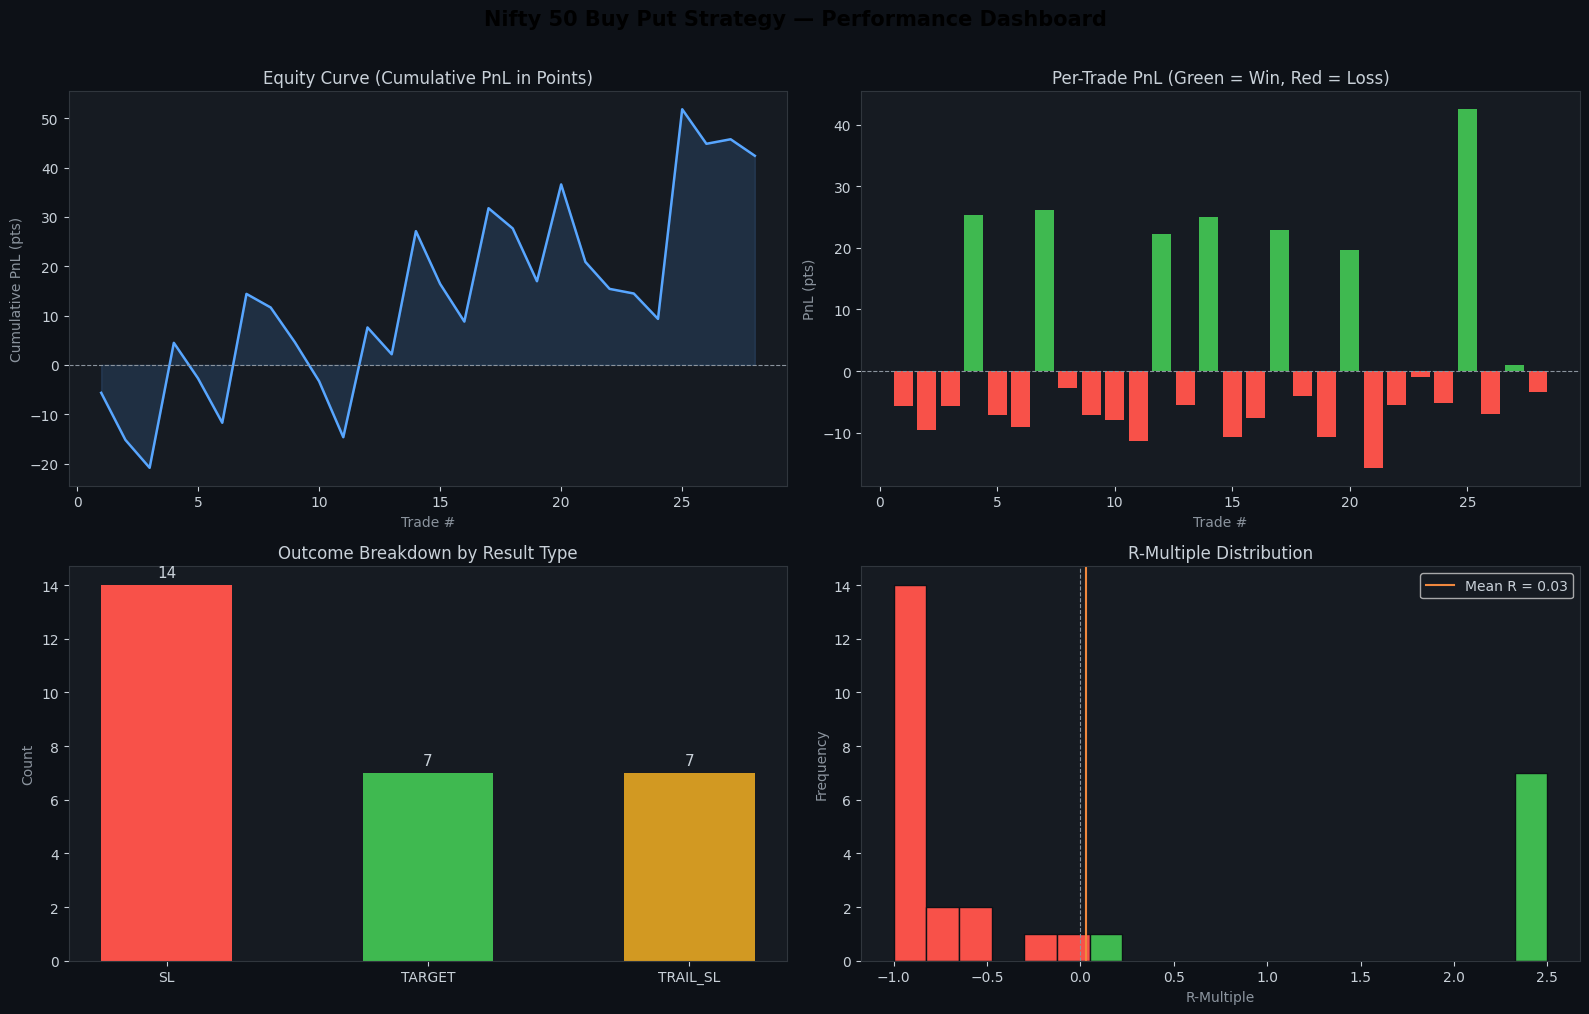

Dashboard saved as nifty_put_dashboard.png


In [21]:
def plot_dashboard(results):
    """4-panel performance dashboard."""
    if results.empty:
        print("No trades to plot.")
        return

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("Nifty 50 Buy Put Strategy — Performance Dashboard",
                 fontsize=15, fontweight="bold", y=1.01)
    fig.patch.set_facecolor("#0d1117")
    for ax in axes.flat:
        ax.set_facecolor("#161b22")
        ax.tick_params(colors="#c9d1d9")
        ax.title.set_color("#c9d1d9")
        for spine in ax.spines.values():
            spine.set_edgecolor("#30363d")

    # ── Panel 1: Equity Curve ──────────────────────────────
    ax1 = axes[0, 0]
    cum_pnl = results["pnl_pts"].cumsum()
    ax1.plot(range(1, len(cum_pnl) + 1), cum_pnl, color="#58a6ff", linewidth=1.8)
    ax1.fill_between(range(1, len(cum_pnl) + 1), cum_pnl, alpha=0.15, color="#58a6ff")
    ax1.axhline(0, color="#8b949e", linestyle="--", linewidth=0.8)
    ax1.set_title("Equity Curve (Cumulative PnL in Points)")
    ax1.set_xlabel("Trade #", color="#8b949e")
    ax1.set_ylabel("Cumulative PnL (pts)", color="#8b949e")

    # ── Panel 2: Per-Trade PnL Bar Chart ───────────────────
    ax2 = axes[0, 1]
    colors = ["#3fb950" if p > 0 else "#f85149" for p in results["pnl_pts"]]
    ax2.bar(range(1, len(results) + 1), results["pnl_pts"], color=colors, width=0.8)
    ax2.axhline(0, color="#8b949e", linestyle="--", linewidth=0.8)
    ax2.set_title("Per-Trade PnL (Green = Win, Red = Loss)")
    ax2.set_xlabel("Trade #", color="#8b949e")
    ax2.set_ylabel("PnL (pts)", color="#8b949e")

    # ── Panel 3: Outcome Breakdown ─────────────────────────
    ax3 = axes[1, 0]
    outcome_colors = {"TARGET": "#3fb950", "SL": "#f85149",
                      "TRAIL_SL": "#d29922", "TIME_EXIT": "#58a6ff"}
    outcome_counts = results["result"].value_counts()
    bar_colors     = [outcome_colors.get(r, "#8b949e") for r in outcome_counts.index]
    ax3.bar(outcome_counts.index, outcome_counts.values, color=bar_colors, width=0.5)
    ax3.set_title("Outcome Breakdown by Result Type")
    ax3.set_ylabel("Count", color="#8b949e")
    for i, (label, val) in enumerate(outcome_counts.items()):
        ax3.text(i, val + 0.3, str(val), ha="center", color="#c9d1d9", fontsize=11)

    # ── Panel 4: R-Multiple Histogram ─────────────────────
    ax4 = axes[1, 1]
    r_vals = results["r_multiple"]
    n, bins, patches = ax4.hist(r_vals, bins=20, edgecolor="#0d1117")
    for patch, left in zip(patches, bins):
        patch.set_facecolor("#3fb950" if left >= 0 else "#f85149")
    ax4.axvline(0,  color="#8b949e", linestyle="--", linewidth=0.8)
    ax4.axvline(r_vals.mean(), color="#f0883e", linestyle="-",
                linewidth=1.5, label=f"Mean R = {r_vals.mean():.2f}")
    ax4.legend(facecolor="#161b22", labelcolor="#c9d1d9")
    ax4.set_title("R-Multiple Distribution")
    ax4.set_xlabel("R-Multiple", color="#8b949e")
    ax4.set_ylabel("Frequency", color="#8b949e")

    plt.tight_layout()
    plt.savefig("nifty_put_dashboard.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print("Dashboard saved as nifty_put_dashboard.png")


plot_dashboard(results)

## 8. Per-Trade Log

In [22]:
def print_trade_log(results):
    """Pretty-print per-trade log."""
    if results.empty:
        print("No trades logged.")
        return

    log = results.copy()
    log["entry_time"] = log["entry_time"].dt.strftime("%d-%b %H:%M")
    log["exit_time"]  = log["exit_time"].dt.strftime("%d-%b %H:%M")
    log["date"]       = log["date"].dt.strftime("%d-%b-%Y")

    display_cols = ["date", "entry_time", "exit_time",
                    "entry", "sl", "target", "exit",
                    "pnl_pts", "r_multiple", "result"]

    # Color flag for readability
    def flag(row):
        if row["result"] == "TARGET":   return "✅"
        if row["result"] == "SL":       return "🔴"
        if row["result"] == "TRAIL_SL": return "🟡"
        return "⏰"

    log["flag"] = log.apply(flag, axis=1)
    print(log[["flag"] + display_cols].to_string(index=True))


print_trade_log(results)

   flag         date    entry_time     exit_time     entry        sl    target      exit  pnl_pts  r_multiple    result
0     🔴  16-Dec-2025  16-Dec 13:25  16-Dec 13:30  25885.30  25890.97  25871.13  25890.97    -5.67       -1.00        SL
1     🔴  17-Dec-2025  17-Dec 13:05  17-Dec 13:15  25793.95  25803.50  25770.07  25803.50    -9.55       -1.00        SL
2     🔴  17-Dec-2025  17-Dec 14:00  17-Dec 14:10  25793.75  25799.40  25779.62  25799.40    -5.65       -1.00        SL
3     ✅  26-Dec-2025  26-Dec 12:20  26-Dec 13:00  26058.20  26052.99  26032.87  26032.87    25.33        2.50    TARGET
4     🔴  26-Dec-2025  26-Dec 13:20  26-Dec 13:30  26046.05  26053.25  26028.05  26053.25    -7.20       -1.00        SL
5     🔴  26-Dec-2025  26-Dec 13:50  26-Dec 14:00  26044.50  26053.50  26022.00  26053.50    -9.00       -1.00        SL
6     ✅  29-Dec-2025  29-Dec 12:10  29-Dec 12:50  25979.90  25974.64  25953.78  25953.78    26.12        2.50    TARGET
7     🟡  29-Dec-2025  29-Dec 13:05  29-D

## 9. Monthly Summary Table

In [23]:
def monthly_summary(results):
    """Generate month-by-month performance table."""
    if results.empty:
        print("No trades to summarize.")
        return

    r = results.copy()
    r["month"] = r["date"].dt.to_period("M")

    summary = r.groupby("month").agg(
        trades   = ("pnl_pts", "count"),
        pnl_pts  = ("pnl_pts", "sum"),
        wins     = ("pnl_pts", lambda x: (x > 0).sum()),
        avg_r    = ("r_multiple", "mean"),
    ).reset_index()

    summary["win_rate"] = (summary["wins"] / summary["trades"] * 100).round(1)
    summary["avg_r"]    = summary["avg_r"].round(2)
    summary["pnl_pts"]  = summary["pnl_pts"].round(1)

    print("\n── Monthly Summary ──────────────────────────────────────")
    print(summary[["month", "trades", "wins", "win_rate", "pnl_pts", "avg_r"]].to_string(index=False))
    print(f"\nCumulative PnL: {summary['pnl_pts'].sum():+.1f} pts")
    return summary


monthly_df = monthly_summary(results)


── Monthly Summary ──────────────────────────────────────
  month  trades  wins  win_rate  pnl_pts  avg_r
2025-12      11     2      18.2    -14.7  -0.32
2026-01       5     2      40.0     23.4   0.46
2026-02      10     3      30.0     36.0   0.22
2026-03       2     1      50.0     -2.4  -0.08

Cumulative PnL: +42.3 pts


## 10. Signal Verification Chart (Last 3 Trading Days)

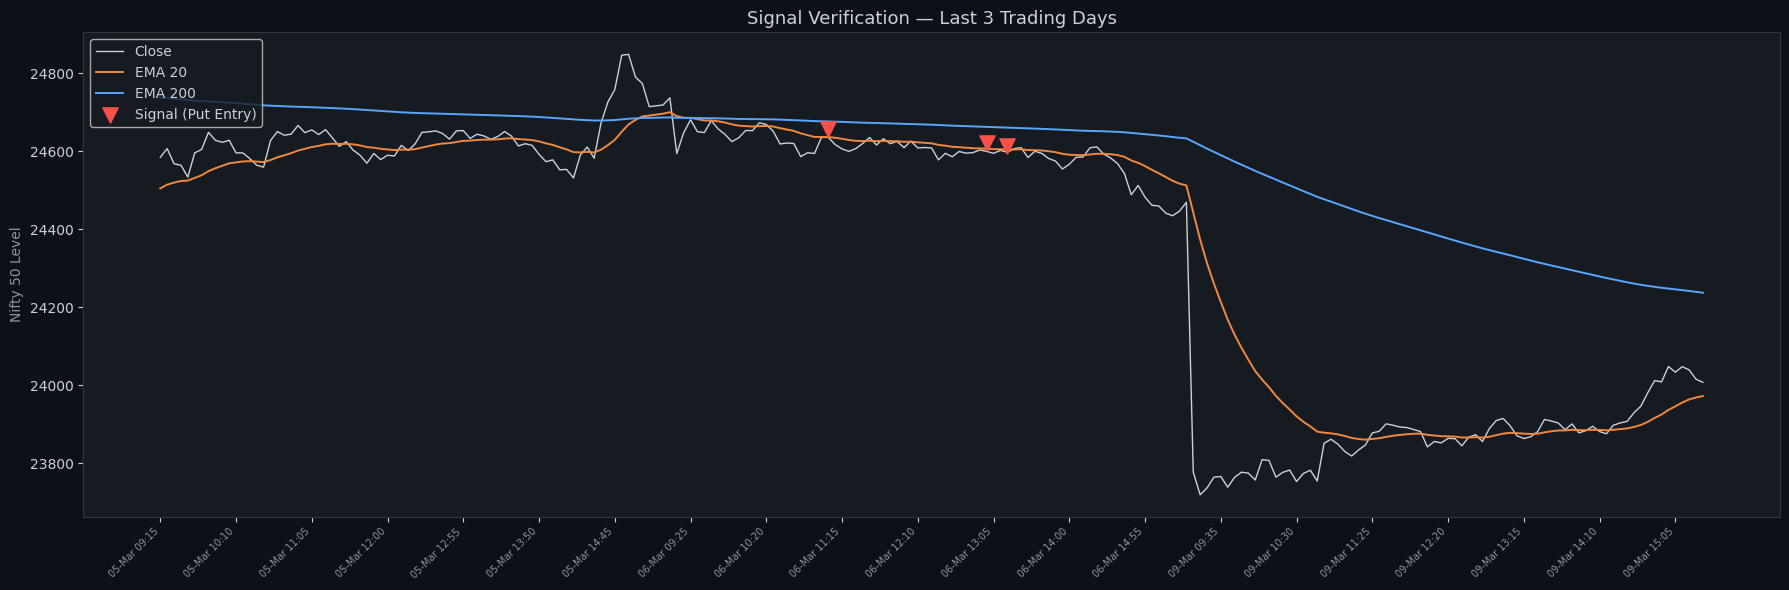

Signal chart saved | Signals on chart: 3


In [25]:
def plot_signal_verification(df, n_days=3):
    """
    Plot Close price, EMA 20, EMA 200 for the last n trading days.
    Mark signal candles with red down-arrows.
    """
    # Get last n trading days — fixed numpy array isin issue
    all_dates  = sorted(set(df.index.date))
    last_days  = set(str(d) for d in all_dates[-n_days:])
    mask       = pd.Series(df.index.date, index=df.index).astype(str).isin(last_days)
    plot_df    = df[mask].copy()

    if plot_df.empty:
        print("Not enough data for signal verification chart.")
        return

    fig, ax = plt.subplots(figsize=(18, 6))
    fig.patch.set_facecolor("#0d1117")
    ax.set_facecolor("#161b22")
    ax.tick_params(colors="#c9d1d9")
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363d")

    x = range(len(plot_df))
    ax.plot(x, plot_df["Close"],  color="#c9d1d9", linewidth=1.0, label="Close", zorder=2)
    ax.plot(x, plot_df["EMA20"],  color="#f0883e", linewidth=1.4, label="EMA 20",  zorder=3)
    ax.plot(x, plot_df["EMA200"], color="#58a6ff", linewidth=1.4, label="EMA 200", zorder=3)

    # Mark signal candles
    signals  = plot_df[plot_df["SIGNAL"]]
    idx_list = list(plot_df.index)
    sig_x    = [idx_list.index(i) for i in signals.index]
    sig_y    = [plot_df.loc[i, "High"] + 8 for i in signals.index]
    ax.scatter(sig_x, sig_y, marker="v", color="#f85149", s=120, zorder=5,
               label="Signal (Put Entry)")

    tick_step = max(1, len(plot_df) // 20)
    ax.set_xticks(list(x)[::tick_step])
    ax.set_xticklabels(
        [plot_df.index[i].strftime("%d-%b %H:%M") for i in range(0, len(x), tick_step)],
        rotation=45, ha="right", fontsize=7, color="#8b949e"
    )

    ax.set_title(f"Signal Verification — Last {n_days} Trading Days",
                 color="#c9d1d9", fontsize=13)
    ax.set_ylabel("Nifty 50 Level", color="#8b949e")
    ax.legend(facecolor="#161b22", labelcolor="#c9d1d9", loc="upper left")

    plt.tight_layout()
    plt.savefig("nifty_put_signals.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"Signal chart saved | Signals on chart: {len(signals)}")


plot_signal_verification(df)

In [26]:
# ═══════════════════════════════════════════════════════════
#  MONEY P&L  — Index Points → Indian Rupees
#  NIFTY 50 lot size = 75 units. Change LOTS_PER_TRADE to scale.
# ═══════════════════════════════════════════════════════════

NIFTY_LOT_SIZE = 65        # current NIFTY 50 lot size
LOTS_PER_TRADE = 1         # ← change to 2, 3 etc. to size up
MULTIPLIER     = NIFTY_LOT_SIZE * LOTS_PER_TRADE

if results.empty:
    print("No trades found.")
else:
    r = results.copy()
    r["pnl_inr"]     = r["pnl_pts"] * MULTIPLIER
    r["cum_pnl_inr"] = r["pnl_inr"].cumsum()

    total_pts       = r["pnl_pts"].sum()
    total_inr       = r["pnl_inr"].sum()
    wins_inr        = r.loc[r["pnl_inr"] > 0,  "pnl_inr"]
    losses_inr      = r.loc[r["pnl_inr"] <= 0, "pnl_inr"]
    avg_win_inr     = wins_inr.mean()   if len(wins_inr)   else 0
    avg_loss_inr    = losses_inr.mean() if len(losses_inr) else 0
    best_trade_inr  = r["pnl_inr"].max()
    worst_trade_inr = r["pnl_inr"].min()
    cum             = r["pnl_inr"].cumsum()
    max_dd_inr      = (cum - cum.cummax()).min()

    print(f"""
╔══════════════════════════════════════════════════════════╗
  MONEY P&L SUMMARY  (NIFTY Buy Put)
  Lot size: {NIFTY_LOT_SIZE} | Lots per trade: {LOTS_PER_TRADE} | Multiplier: {MULTIPLIER}x
╠══════════════════════════════════════════════════════════╣
  Total Trades          : {len(r)}
  Total PnL (pts)       : {total_pts:+.1f} pts
  Total PnL (Rs)        : Rs {total_inr:+,.0f}
  ----------------------------------------------------------
  Avg Win  (Rs)         : Rs {avg_win_inr:+,.0f}
  Avg Loss (Rs)         : Rs {avg_loss_inr:+,.0f}
  Best Single Trade(Rs) : Rs {best_trade_inr:+,.0f}
  Worst Single Trade(Rs): Rs {worst_trade_inr:+,.0f}
  Max Drawdown (Rs)     : Rs {max_dd_inr:,.0f}
╚══════════════════════════════════════════════════════════╝
""")

    # Monthly money breakdown
    r["month"] = r["date"].dt.to_period("M")
    monthly_inr = r.groupby("month").agg(
        Trades  = ("pnl_inr", "count"),
        PnL_INR = ("pnl_inr", "sum"),
        Wins    = ("pnl_inr", lambda x: (x > 0).sum()),
    ).reset_index()
    monthly_inr["Win_pct"] = (monthly_inr["Wins"] / monthly_inr["Trades"] * 100).round(1)
    monthly_inr["PnL_str"] = monthly_inr["PnL_INR"].apply(lambda x: f"Rs {x:+,.0f}")
    display_cols = monthly_inr[["month", "Trades", "Wins", "Win_pct", "PnL_str"]]
    display_cols.columns = ["Month", "Trades", "Wins", "Win%", "PnL (Rs)"]
    print(display_cols.to_string(index=False))
    print(f"\n  Grand Total: Rs {total_inr:+,.0f}  ({total_pts:+.1f} pts x {MULTIPLIER})")



╔══════════════════════════════════════════════════════════╗
  MONEY P&L SUMMARY  (NIFTY Buy Put)
  Lot size: 75 | Lots per trade: 1 | Multiplier: 75x
╠══════════════════════════════════════════════════════════╣
  Total Trades          : 28
  Total PnL (pts)       : +42.4 pts
  Total PnL (Rs)        : Rs +3,178
  ----------------------------------------------------------
  Avg Win  (Rs)         : Rs +1,731
  Avg Loss (Rs)         : Rs -534
  Best Single Trade(Rs) : Rs +3,188
  Worst Single Trade(Rs): Rs -1,178
  Max Drawdown (Rs)     : Rs -2,179
╚══════════════════════════════════════════════════════════╝

  Month  Trades  Wins  Win%  PnL (Rs)
2025-12      11     2  18.2 Rs -1,100
2026-01       5     2  40.0 Rs +1,758
2026-02      10     3  30.0 Rs +2,703
2026-03       2     1  50.0   Rs -182

  Grand Total: Rs +3,178  (+42.4 pts x 75)
